# H100x8 GPU-only vs Hybrid Comparison

이 노트북은 `eval/basic/H100x8` 하위 결과를 자동으로 스캔해서 GPU-only 기준선과 hybrid 실행들을 비교합니다.

분석 기준:

- 결과 JSON: `gpu_only.json`, `hybrid.json`
- 설정 JSON: `system_info.json`
- 로그: `hybrid_server_boot.log`, `hybrid_server_run.log`
- `inspect.txt` 같은 후처리 산출물은 사용하지 않습니다.

주요 질문:

- GPU-only 대비 hybrid wall time / throughput이 얼마나 악화 또는 개선되는가
- CPU가 실제로 몇 개 request를 가져갔는가
- `cpu_max_num_seqs=1`과 `16`의 차이가 tail로 어떻게 드러나는가
- CPU pinning만 달라졌는지, 실행 패턴도 달라졌는지


## Embedded Figures

아래 그림은 노트북 파일 자체에 output으로 저장되어 있습니다. 노트북을 다시 실행하지 않아도 보여야 합니다.


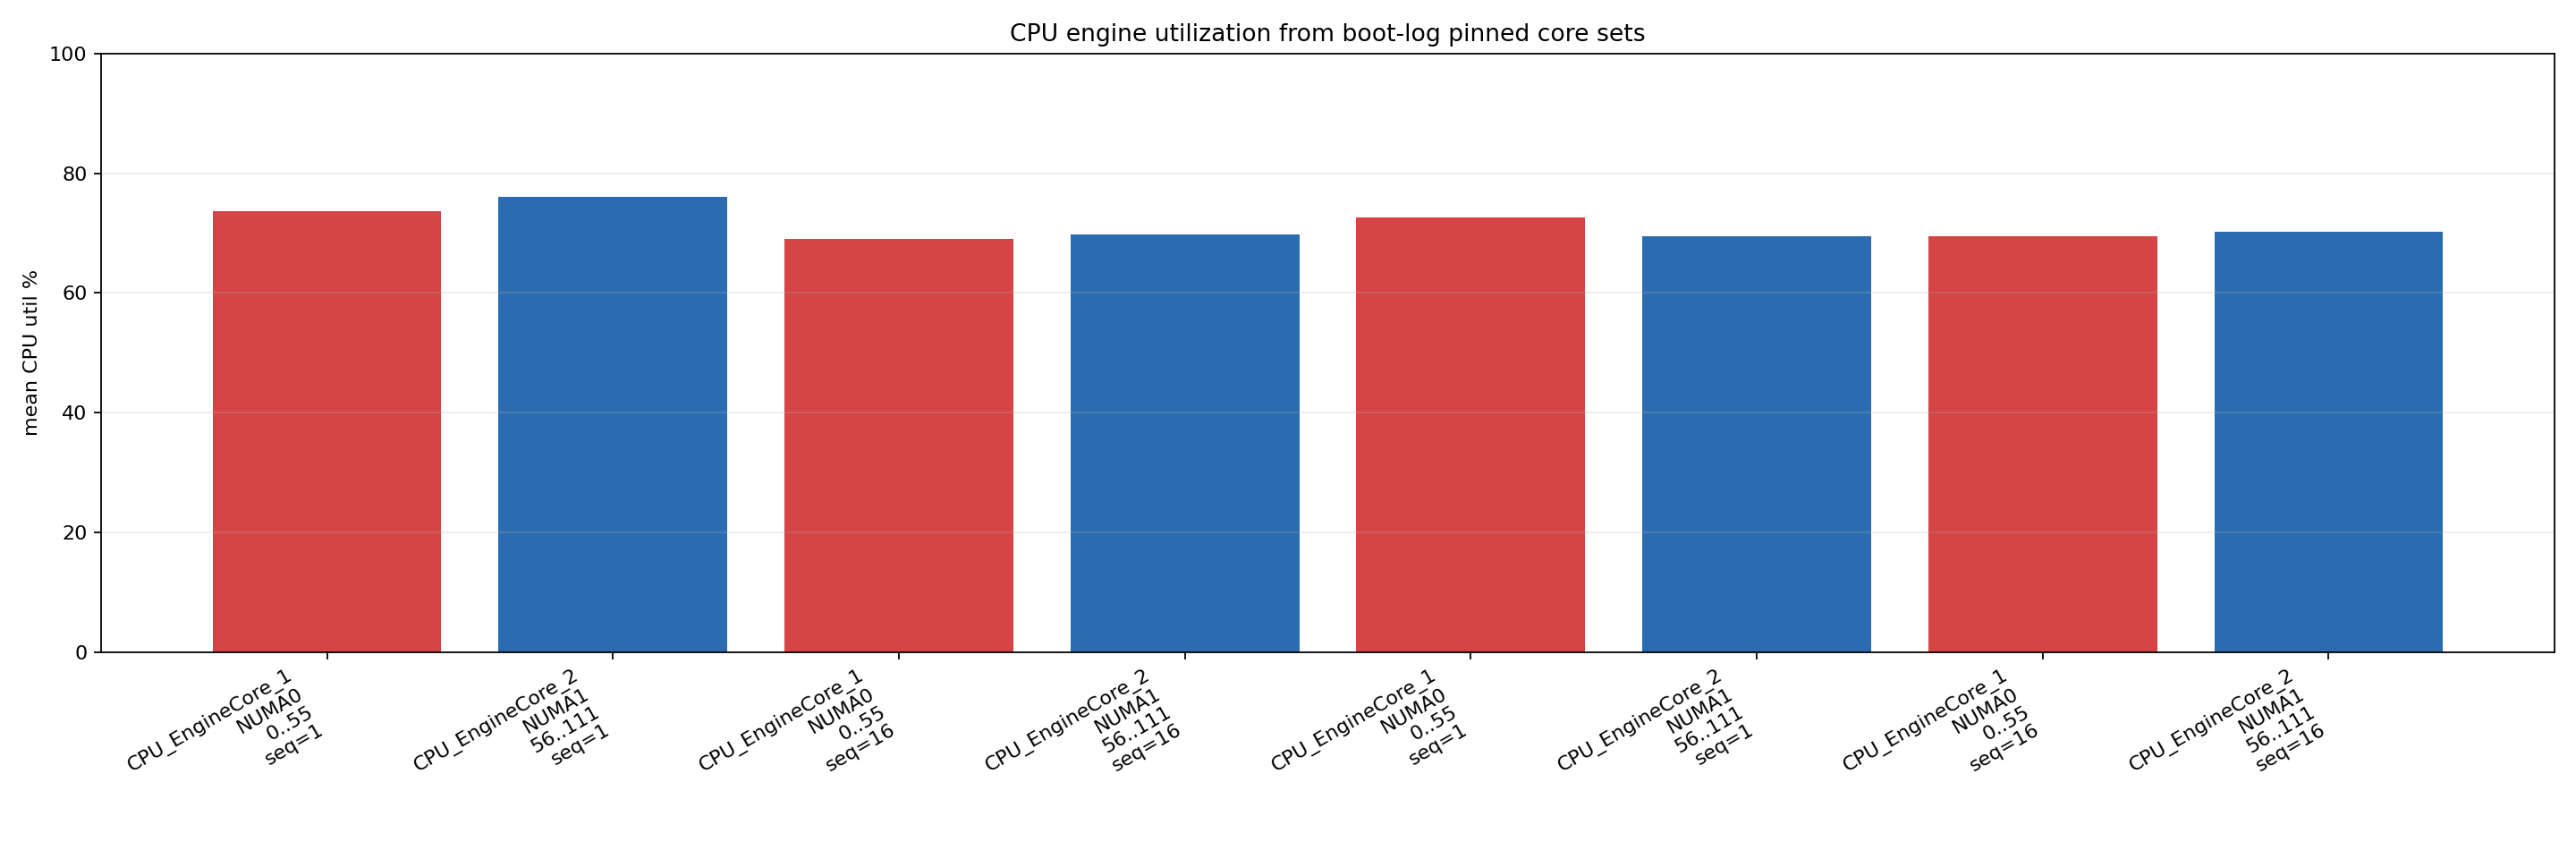

In [1]:
# CPU engine utilization


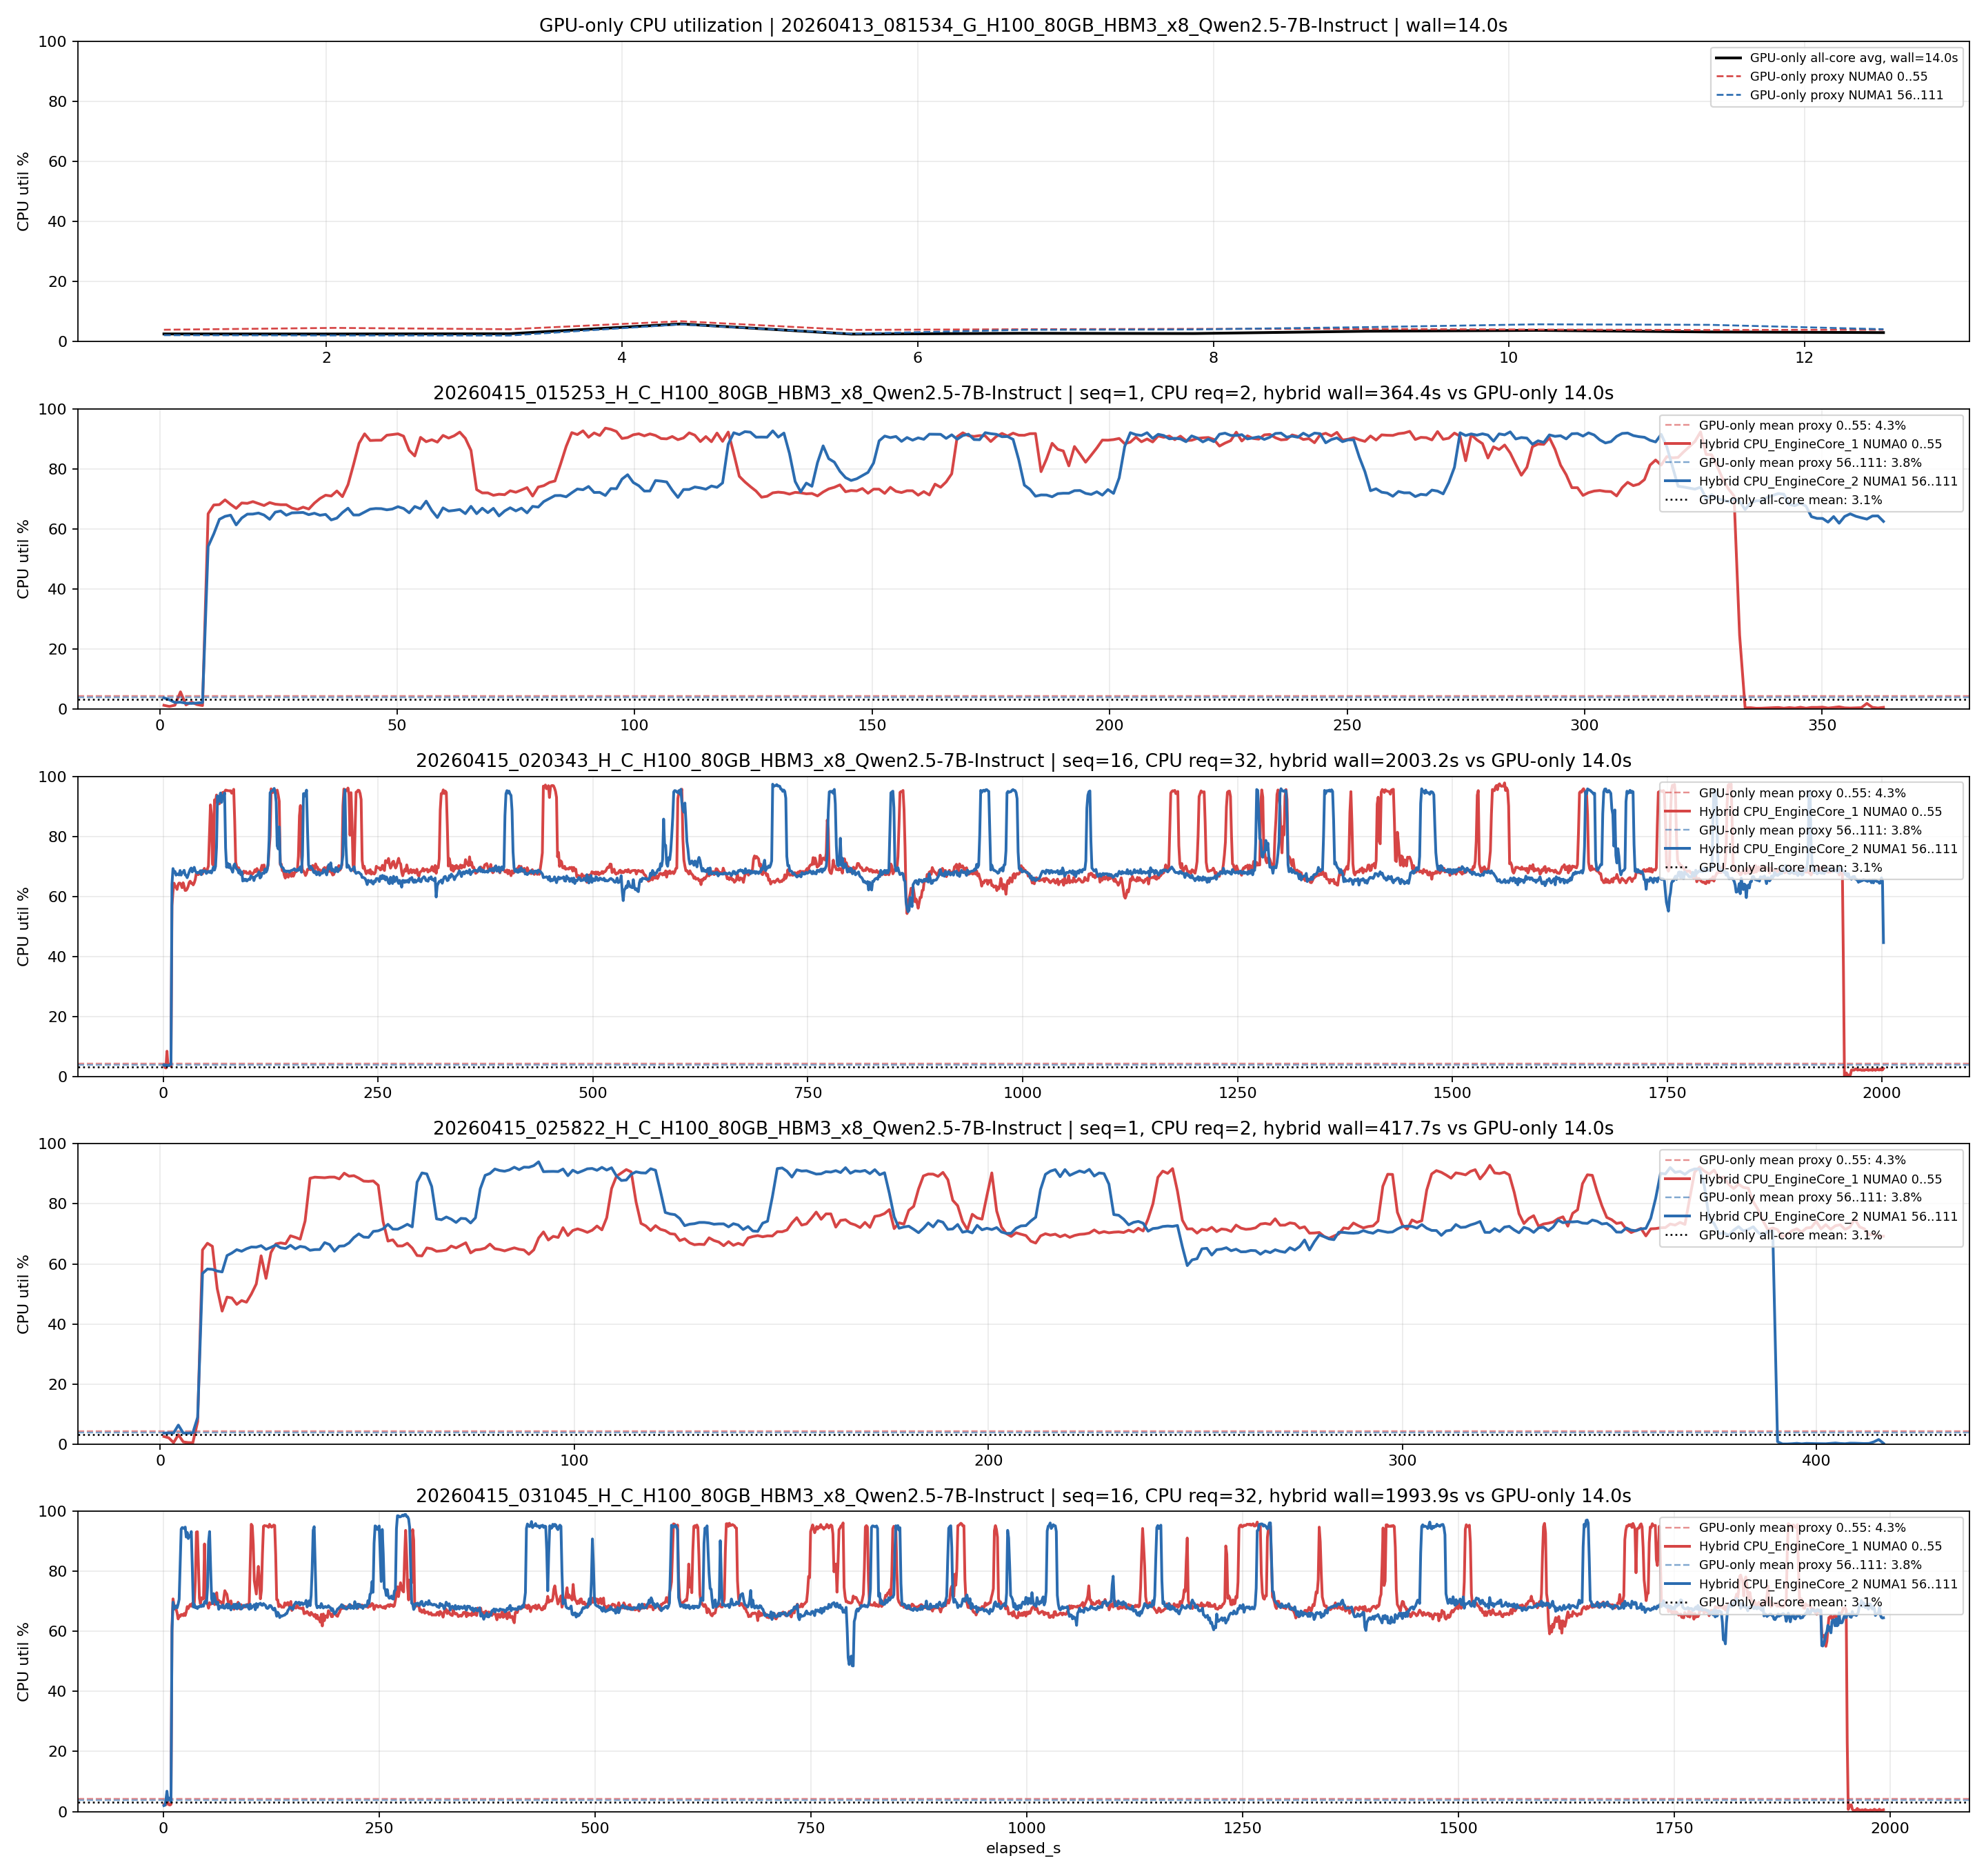

In [1]:
# CPU pinned core timeline vs GPU-only


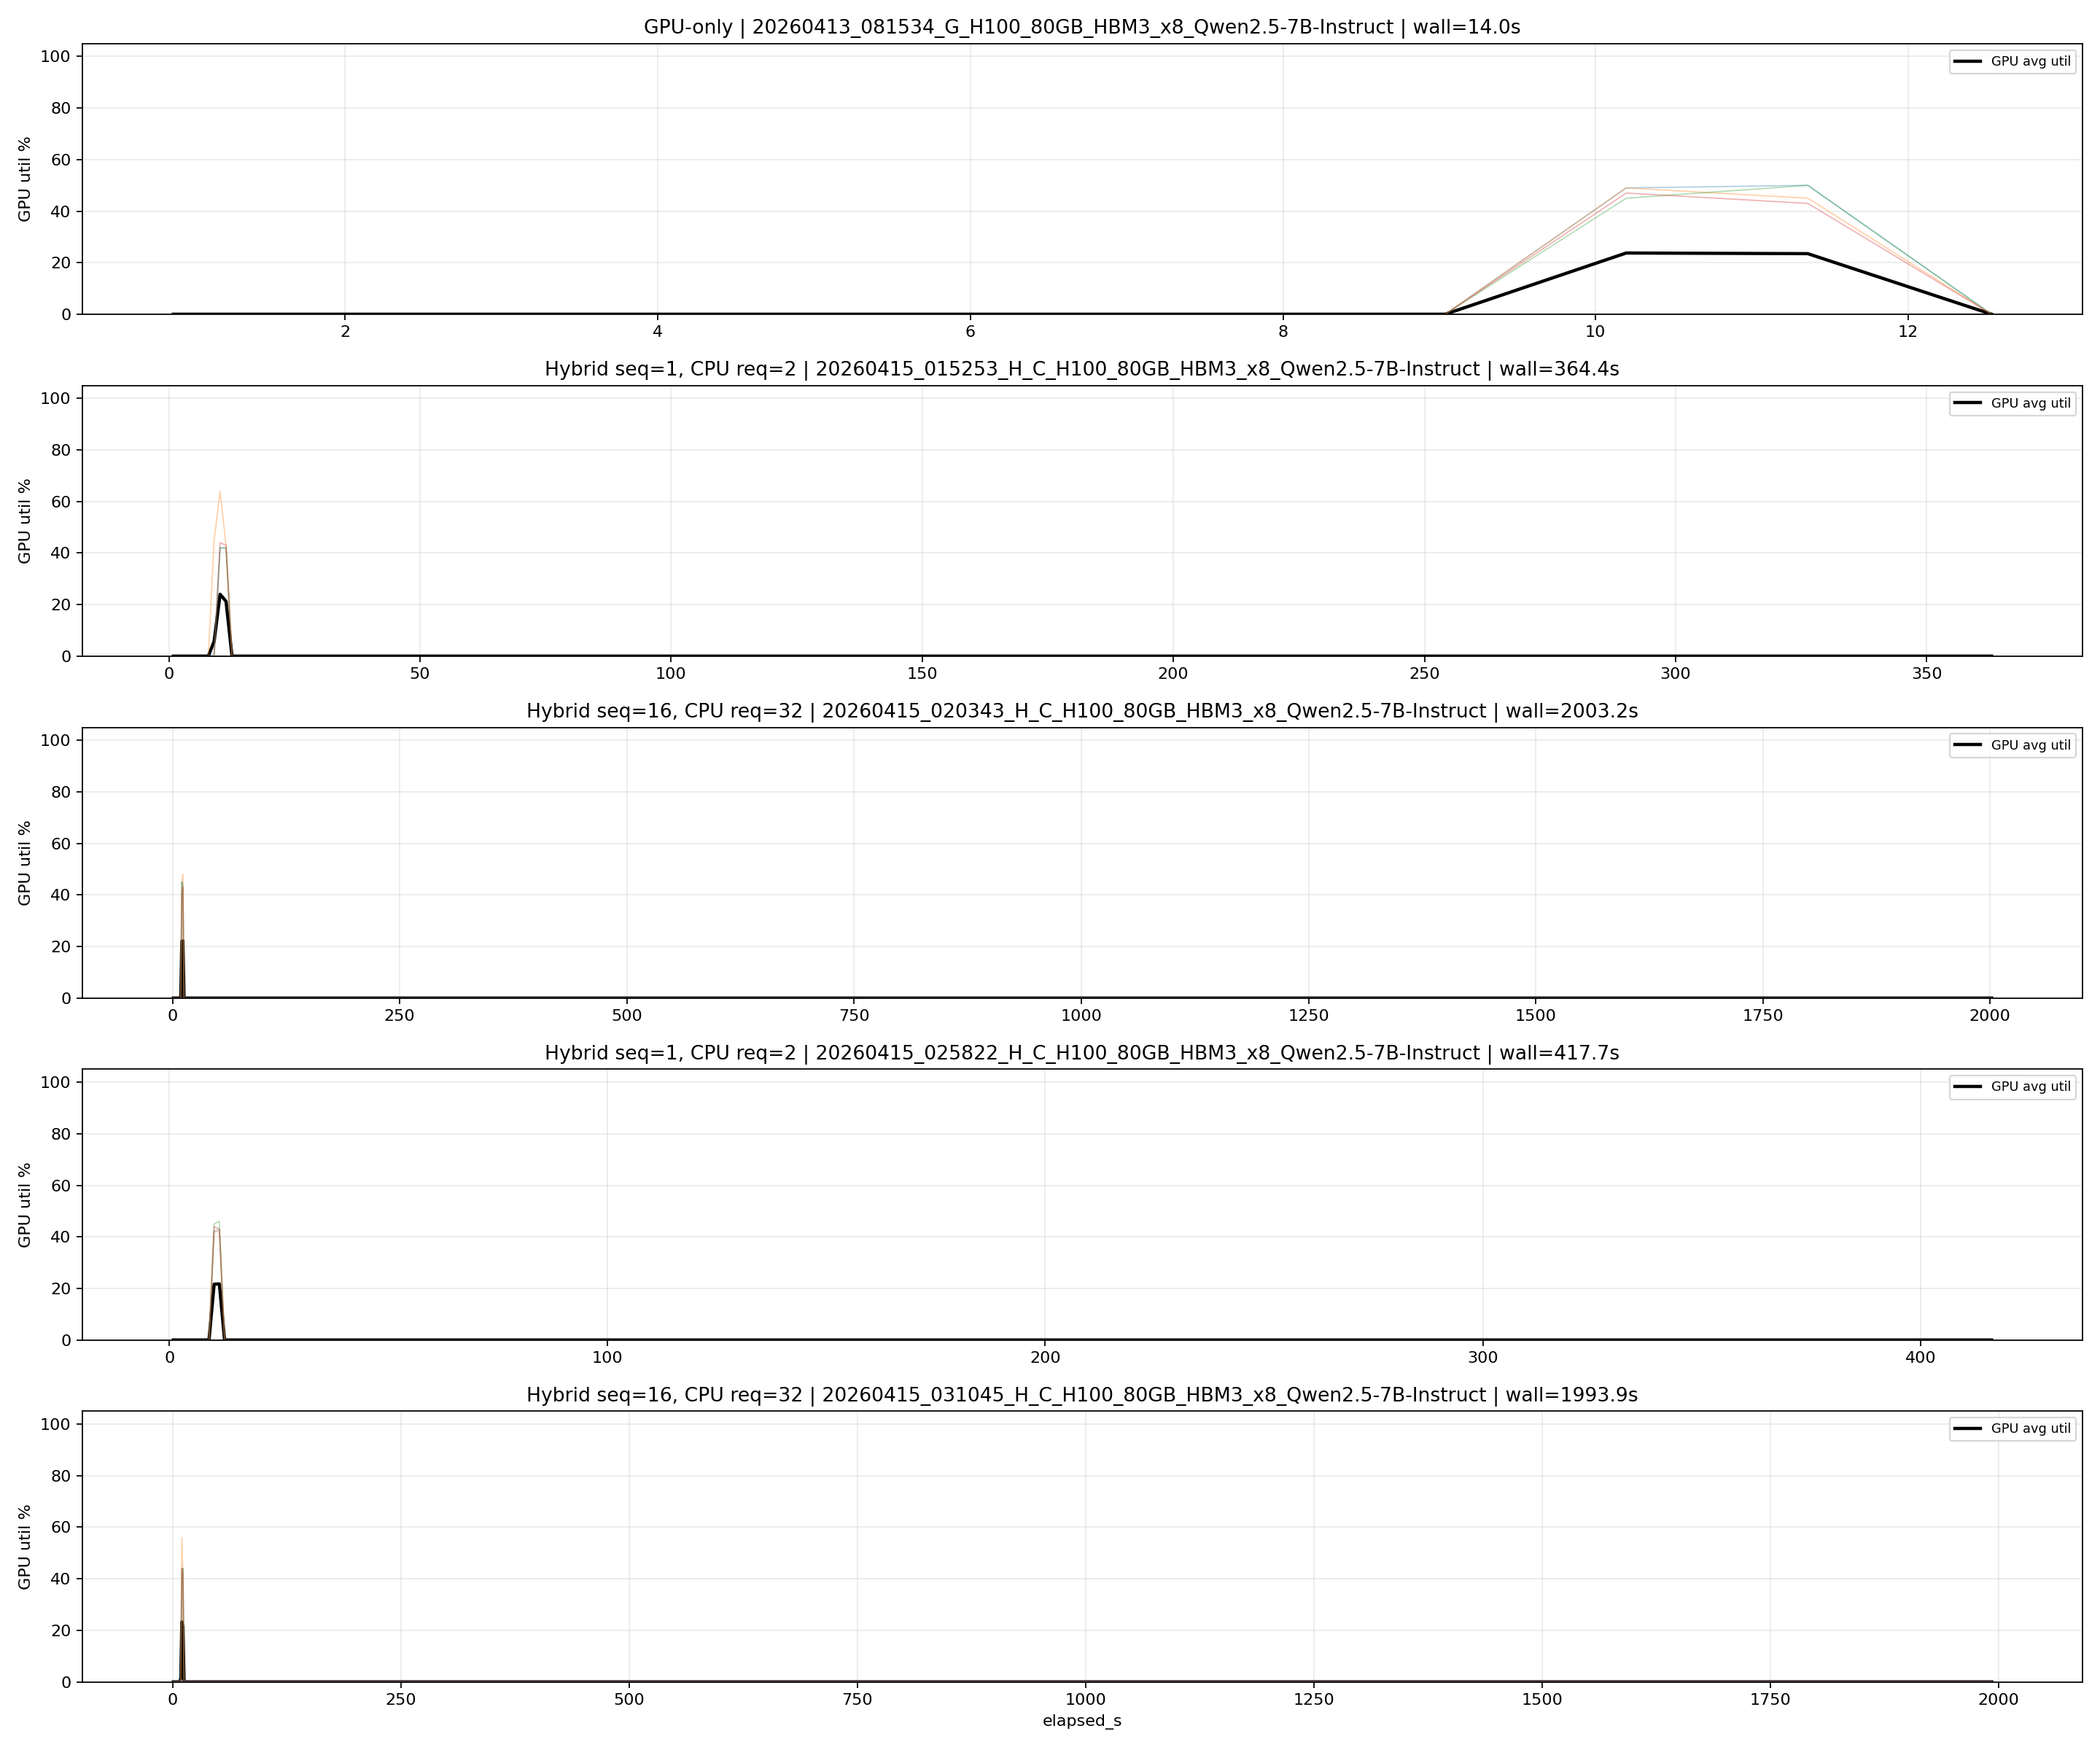

In [1]:
# GPU utilization timeline


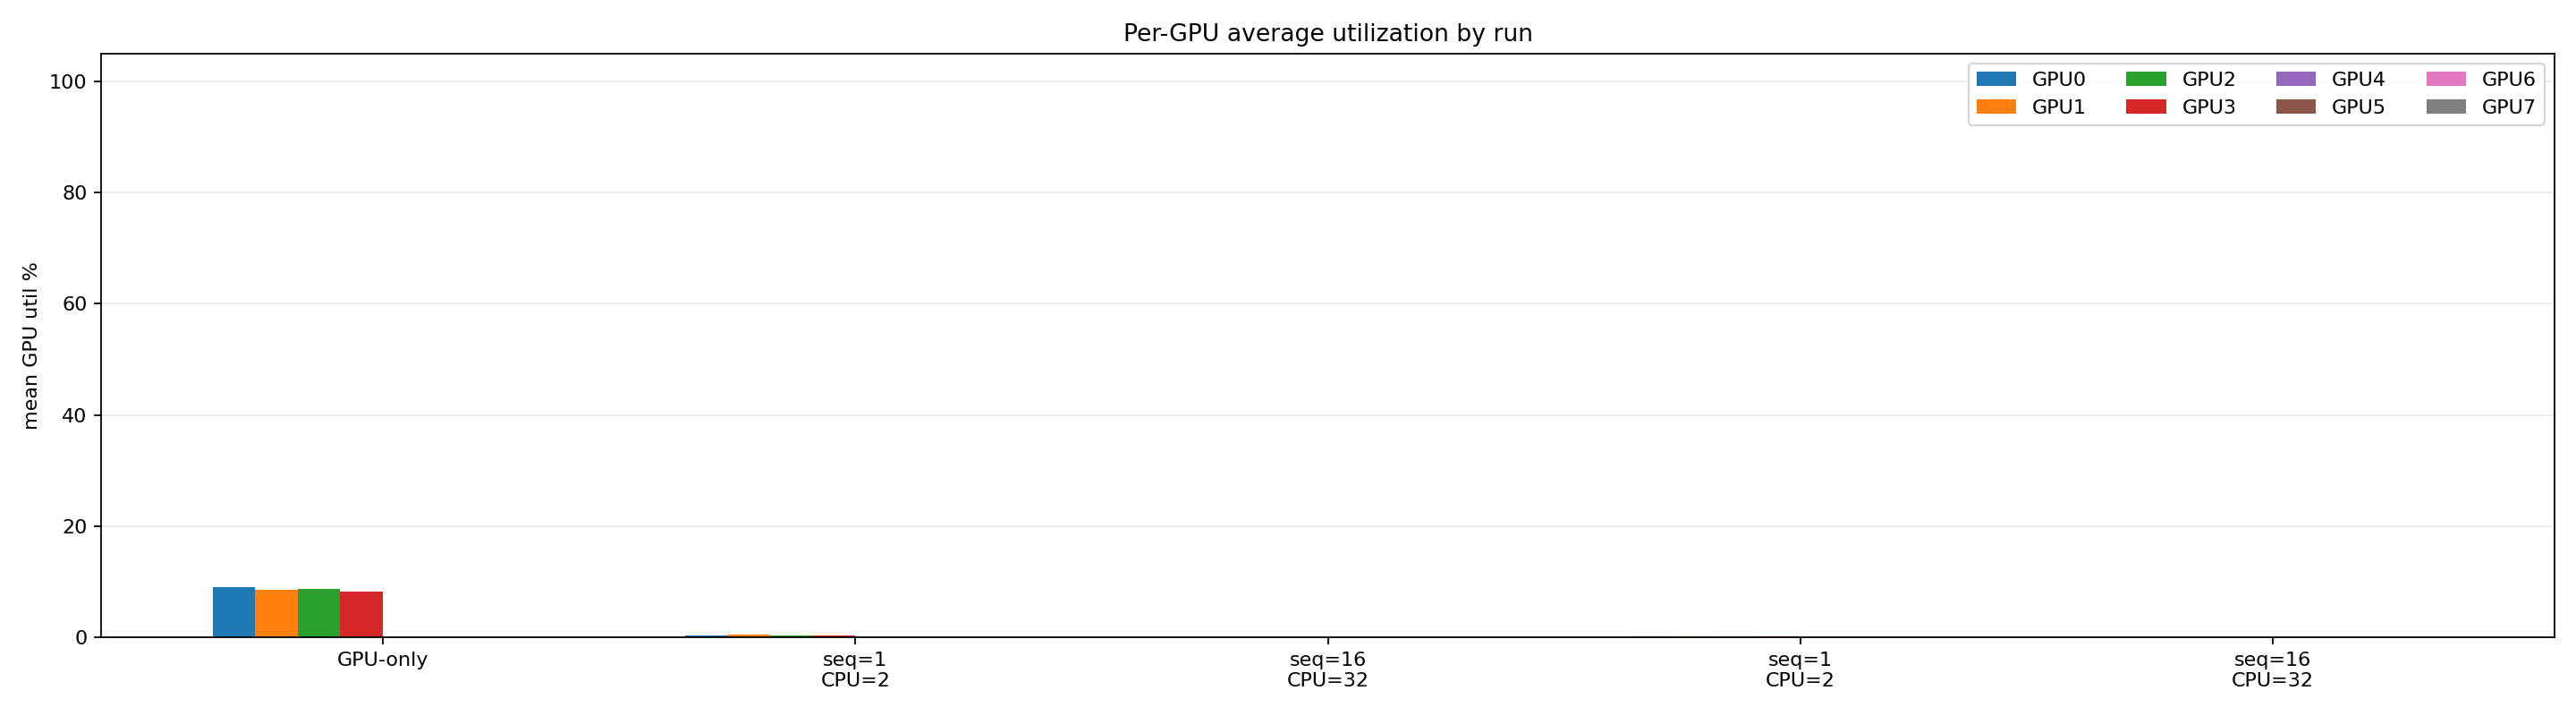

In [1]:
# Per-GPU average utilization


In [ ]:
from __future__ import annotations

import json
import math
import os
import re
from pathlib import Path

import pandas as pd
try:
    from IPython.display import display, Markdown
except ModuleNotFoundError:
    def display(obj):
        print(obj)
    def Markdown(text):
        return text

try:
    os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")
    import matplotlib.pyplot as plt
except ModuleNotFoundError:
    plt = None

ROOT = Path.cwd()
if ROOT.name != "H100x8":
    ROOT = Path("/vllm_hybrid/eval/basic/H100x8")

assert ROOT.exists(), ROOT
ROOT


## Parsing Helpers

In [ ]:
ANSI_RE = re.compile(r"\x1b\[[0-9;]*m")


def read_text(path: Path) -> str:
    if not path.exists():
        return ""
    return ANSI_RE.sub("", path.read_text(errors="ignore"))


def load_json(path: Path) -> dict:
    if not path.exists():
        return {}
    return json.loads(path.read_text())


def to_int(value, default=None):
    try:
        if value in (None, "", "auto"):
            return default
        return int(value)
    except Exception:
        return default


def short_cpu_list(cpu_ids: str, max_items: int = 8) -> str:
    if not cpu_ids:
        return ""
    parts = [p.strip() for p in cpu_ids.split(",") if p.strip()]
    if len(parts) <= max_items * 2:
        return ",".join(parts)
    return ",".join(parts[:max_items]) + " ... " + ",".join(parts[-max_items:])


def parse_run_log(text: str) -> dict:
    router = re.search(
        r"HYBRID-ROUTER-INIT.*?strategy=(\S+) priority=(\S+) "
        r"cpu_max_num_seqs=(\d+) num_cpu_engines=(\d+).*?gate=([^ ]+)",
        text,
    )
    dispatch = re.findall(
        r"HYBRID-ROUTER-DISPATCH.*?n=(\d+).*?cpu_count=(\d+) "
        r"gpu_count=(\d+) cpu_in_flight=(\d+) gpu_in_flight=(\d+)",
        text,
    )
    waves = re.findall(
        r"HYBRID-WAVE.*?engine=(\d+) wave closed "
        r"\(accepted=(\d+), batch_size=(\d+)\)",
        text,
    )
    drains = re.findall(
        r"HYBRID-WAVE.*?engine=(\d+) wave drained \(accepted=(\d+)\)",
        text,
    )
    stats = re.findall(
        r"HYBRID-ROUTER-STATS.*?GPU=.*?\((\d+) reqs\), "
        r"CPU=.*?\((\d+) reqs\), in_flight_cpu=(\d+)/(\d+)",
        text,
    )

    last_dispatch = dispatch[-1] if dispatch else None
    last_stats = stats[-1] if stats else None
    return {
        "router_strategy_log": router.group(1) if router else None,
        "router_priority_log": router.group(2) if router else None,
        "cpu_max_num_seqs_log": to_int(router.group(3)) if router else None,
        "num_cpu_engines_log": to_int(router.group(4)) if router else None,
        "router_gate": router.group(5) if router else None,
        "dispatch_n": to_int(last_dispatch[0]) if last_dispatch else None,
        "dispatch_cpu_count": to_int(last_dispatch[1]) if last_dispatch else None,
        "dispatch_gpu_count": to_int(last_dispatch[2]) if last_dispatch else None,
        "dispatch_cpu_in_flight": to_int(last_dispatch[3]) if last_dispatch else None,
        "dispatch_gpu_in_flight": to_int(last_dispatch[4]) if last_dispatch else None,
        "wave_closed_events": len(waves),
        "wave_closed_total_accepted": sum(to_int(w[1], 0) for w in waves),
        "wave_closed_detail": "; ".join(
            f"e{e}:accepted={a},batch={b}" for e, a, b in waves
        ),
        "wave_drained_events": len(drains),
        "wave_drained_total_accepted": sum(to_int(d[1], 0) for d in drains),
        "wave_drained_detail": "; ".join(
            f"e{e}:accepted={a}" for e, a in drains
        ),
        "stats_gpu_reqs": to_int(last_stats[0]) if last_stats else None,
        "stats_cpu_reqs": to_int(last_stats[1]) if last_stats else None,
        "stats_in_flight_cpu": to_int(last_stats[2]) if last_stats else None,
        "stats_cpu_max_num_seqs": to_int(last_stats[3]) if last_stats else None,
    }


def parse_boot_log(text: str) -> dict:
    cpus = re.findall(r"local_omp_cpuid='([^']+)'", text)
    post = re.findall(
        r"post-init: torch_threads=(\d+) process_threads=(\d+) "
        r"cpu_affinity=(\d+) cores ([^\n]+)",
        text,
    )
    envs = re.findall(
        r"HYBRID-CPU-ENV.*?OMP=(\d+).*?ONEDNN_ISA=([^ ]+) "
        r"BIND=([^ ]+) sched_affinity_count=(\d+)",
        text,
    )
    return {
        "cpu_pinning_lists": " | ".join(short_cpu_list(c) for c in cpus),
        "cpu_pinning_counts": " | ".join(str(len([x for x in c.split(',') if x])) for c in cpus),
        "post_torch_threads": " | ".join(p[0] for p in post),
        "post_process_threads": " | ".join(p[1] for p in post),
        "env_omp": " | ".join(e[0] for e in envs),
        "env_onednn_isa": " | ".join(sorted(set(e[1] for e in envs))),
        "env_bind": " | ".join(sorted(set(e[2] for e in envs))),
        "sched_affinity_count": " | ".join(e[3] for e in envs),
    }


## Load Results

In [ ]:
rows = []

for d in sorted(p for p in ROOT.iterdir() if p.is_dir()):
    result_path = d / "gpu_only.json"
    mode = "gpu_only" if result_path.exists() else "hybrid"
    if mode == "hybrid":
        result_path = d / "hybrid.json"
    if not result_path.exists():
        continue

    result = load_json(result_path)
    system = load_json(d / "system_info.json")
    hybrid_cfg = system.get("hybrid_config", {})
    bench_cfg = system.get("benchmark_config", {})

    run_info = parse_run_log(read_text(d / "hybrid_server_run.log"))
    boot_info = parse_boot_log(read_text(d / "hybrid_server_boot.log"))

    row = {
        "run_dir": d.name,
        "mode": mode,
        "date": result.get("date"),
        "model_id": result.get("model_id"),
        "num_prompts": result.get("num_prompts"),
        "completed": result.get("completed"),
        "duration_s": result.get("duration"),
        "wall_time_s": result.get("wall_time_s"),
        "request_throughput": result.get("request_throughput"),
        "output_throughput": result.get("output_throughput"),
        "total_token_throughput": result.get("total_token_throughput"),
        "mean_ttft_ms": result.get("mean_ttft_ms"),
        "p99_ttft_ms": result.get("p99_ttft_ms"),
        "mean_tpot_ms": result.get("mean_tpot_ms"),
        "p99_tpot_ms": result.get("p99_tpot_ms"),
        "routing_strategy_cfg": hybrid_cfg.get("routing_strategy"),
        "routing_priority_cfg": hybrid_cfg.get("routing_priority"),
        "cpu_max_seqs_cfg": to_int(hybrid_cfg.get("cpu_max_seqs")),
        "cpu_threads_cfg": to_int(hybrid_cfg.get("cpu_threads")),
        "num_cpu_engines_cfg": to_int(hybrid_cfg.get("num_cpu_engines")),
        "numa_aware_cfg": hybrid_cfg.get("numa_aware"),
        "input_len": to_int(bench_cfg.get("input_len")),
        "output_len": to_int(bench_cfg.get("output_len")),
        "request_rate": bench_cfg.get("request_rate") or result.get("request_rate"),
    }
    row.update(run_info)
    row.update(boot_info)
    rows.append(row)

df = pd.DataFrame(rows).sort_values(["mode", "date", "run_dir"]).reset_index(drop=True)

gpu = df[df["mode"] == "gpu_only"].sort_values("date").iloc[-1]
gpu_wall = float(gpu["wall_time_s"])
gpu_duration = float(gpu["duration_s"])
gpu_req_tps = float(gpu["request_throughput"])
gpu_out_tps = float(gpu["output_throughput"])

df["wall_vs_gpu_x"] = df["wall_time_s"] / gpu_wall
df["duration_vs_gpu_x"] = df["duration_s"] / gpu_duration
df["request_tput_vs_gpu"] = df["request_throughput"] / gpu_req_tps
df["output_tput_vs_gpu"] = df["output_throughput"] / gpu_out_tps
df["estimated_cpu_tail_s"] = df["wall_time_s"] - gpu_wall
df.loc[df["mode"] == "gpu_only", "estimated_cpu_tail_s"] = 0.0

df


## Executive Summary

In [ ]:
hy = df[df["mode"] == "hybrid"].copy()

summary_lines = [
    f"- GPU-only baseline: wall={gpu_wall:.2f}s, duration={gpu_duration:.2f}s, request throughput={gpu_req_tps:.2f} req/s, output throughput={gpu_out_tps:.0f} tok/s.",
]

if not hy.empty:
    best_wall = hy.loc[hy["wall_time_s"].idxmin()]
    worst_wall = hy.loc[hy["wall_time_s"].idxmax()]
    summary_lines.extend([
        f"- Best hybrid wall: {best_wall['run_dir']} wall={best_wall['wall_time_s']:.2f}s ({best_wall['wall_vs_gpu_x']:.1f}x GPU-only).",
        f"- Worst hybrid wall: {worst_wall['run_dir']} wall={worst_wall['wall_time_s']:.2f}s ({worst_wall['wall_vs_gpu_x']:.1f}x GPU-only).",
        "- Hybrid runs still show the same pattern: GPU bulk finishes quickly, then CPU wave drain dominates total wall time.",
        "- The visible changed dimension in the 20260415 runs is CPU pinning range; routing/wave behavior remains the same shape as prior analysis.",
    ])

display(Markdown("\n".join(summary_lines)))


## Result Table: GPU-only Baseline vs Hybrid

In [ ]:
cols = [
    "run_dir", "mode", "wall_time_s", "duration_s", "wall_vs_gpu_x",
    "request_throughput", "request_tput_vs_gpu", "output_throughput",
    "output_tput_vs_gpu", "mean_ttft_ms", "mean_tpot_ms",
    "cpu_max_seqs_cfg", "cpu_threads_cfg", "num_cpu_engines_cfg",
    "dispatch_cpu_count", "dispatch_gpu_count", "estimated_cpu_tail_s",
]

display(
    df[cols]
    .sort_values(["mode", "cpu_max_seqs_cfg", "cpu_threads_cfg", "wall_time_s"], na_position="first")
    .style.format({
        "wall_time_s": "{:.2f}",
        "duration_s": "{:.2f}",
        "wall_vs_gpu_x": "{:.1f}x",
        "request_throughput": "{:.3f}",
        "request_tput_vs_gpu": "{:.4f}",
        "output_throughput": "{:.1f}",
        "output_tput_vs_gpu": "{:.4f}",
        "mean_ttft_ms": "{:.1f}",
        "mean_tpot_ms": "{:.1f}",
        "estimated_cpu_tail_s": "{:.1f}",
    })
)


## Routing / Wave Evidence from Logs

In [ ]:
routing_cols = [
    "run_dir", "routing_strategy_cfg", "routing_priority_cfg",
    "cpu_max_seqs_cfg", "cpu_threads_cfg", "num_cpu_engines_cfg",
    "cpu_max_num_seqs_log", "num_cpu_engines_log", "router_gate",
    "dispatch_n", "dispatch_cpu_count", "dispatch_gpu_count",
    "wave_closed_events", "wave_closed_total_accepted", "wave_closed_detail",
    "wave_drained_events", "wave_drained_total_accepted", "wave_drained_detail",
]

display(df[df["mode"] == "hybrid"][routing_cols].sort_values("run_dir"))


## CPU Pinning Evidence from Boot Logs

이 표는 서버 부팅 로그에 직접 찍힌 `local_omp_cpuid`만 사용합니다. topology 해석이나 `inspect.txt`는 사용하지 않습니다.

In [ ]:
pin_cols = [
    "run_dir", "cpu_max_seqs_cfg", "cpu_threads_cfg", "num_cpu_engines_cfg",
    "env_omp", "post_torch_threads", "sched_affinity_count",
    "env_onednn_isa", "env_bind", "cpu_pinning_counts", "cpu_pinning_lists",
]

display(df[df["mode"] == "hybrid"][pin_cols].sort_values("run_dir"))


## Plots

In [ ]:
if plt is None:
    display(Markdown("`matplotlib` is not installed in this environment, so plots are skipped. The tables above contain the same data."))
else:
    plot_df = df.copy()
    plot_df["label"] = plot_df.apply(
        lambda r: "GPU-only" if r["mode"] == "gpu_only" else f"seq={int(r['cpu_max_seqs_cfg'])},thr={int(r['cpu_threads_cfg'])}",
        axis=1,
    )

    fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

    axes[0].bar(plot_df["label"], plot_df["wall_time_s"])
    axes[0].set_title("Wall time (s)")
    axes[0].set_ylabel("seconds")
    axes[0].tick_params(axis="x", rotation=35)

    axes[1].bar(plot_df["label"], plot_df["wall_vs_gpu_x"])
    axes[1].set_title("Wall slowdown vs GPU-only")
    axes[1].set_ylabel("x GPU-only")
    axes[1].tick_params(axis="x", rotation=35)

    hy_plot = plot_df[plot_df["mode"] == "hybrid"]
    x = range(len(hy_plot))
    axes[2].bar(x, hy_plot["dispatch_gpu_count"], label="GPU requests")
    axes[2].bar(x, hy_plot["dispatch_cpu_count"], bottom=hy_plot["dispatch_gpu_count"], label="CPU requests")
    axes[2].set_xticks(list(x), hy_plot["label"], rotation=35)
    axes[2].set_title("Final dispatch split")
    axes[2].set_ylabel("requests")
    axes[2].legend()

    plt.tight_layout()
    plt.show()


## GPU Utilization Timeline

GPU 사용률은 각 run의 GPU monitor CSV를 기준으로 그립니다. GPU-only와 hybrid 4개 run 모두 포함합니다.

사용 파일:

- GPU-only: `gpu_only_monitor_gpu.csv`
- Hybrid: `hybrid_monitor_gpu.csv`


In [ ]:
def load_gpu_monitor(run_dir: str, mode: str | None = None) -> pd.DataFrame:
    if mode is None:
        row = df[df["run_dir"] == run_dir]
        mode = row.iloc[0]["mode"] if not row.empty else "hybrid"
    filename = "gpu_only_monitor_gpu.csv" if mode == "gpu_only" else "hybrid_monitor_gpu.csv"
    path = ROOT / run_dir / filename
    if not path.exists():
        return pd.DataFrame()
    g = pd.read_csv(path)
    for c in g.columns:
        if c.endswith(("_util_pct", "_mem_util_pct", "_mem_used_mb", "_power_w", "_temp_c")) or c in {"elapsed_s", "gpu_avg_util_pct", "gpu_avg_mem_util_pct", "gpu_avg_power_w"}:
            g[c] = pd.to_numeric(g[c], errors="coerce")
    return g

if plt is None:
    display(Markdown("`matplotlib` is not installed, so GPU utilization plots are skipped."))
else:
    plot_runs = df.sort_values(["mode", "date", "run_dir"]).copy()
    gpu_only_rows = plot_runs[plot_runs["mode"] == "gpu_only"]
    hybrid_rows = plot_runs[plot_runs["mode"] == "hybrid"]
    ordered = pd.concat([gpu_only_rows, hybrid_rows], ignore_index=True)

    fig, axes = plt.subplots(len(ordered), 1, figsize=(18, 3.0 * len(ordered)), sharex=False)
    if len(ordered) == 1:
        axes = [axes]
    for ax, row in zip(axes, ordered.itertuples()):
        g = load_gpu_monitor(row.run_dir, mode=row.mode)
        if g.empty:
            ax.text(0.5, 0.5, "missing GPU monitor", transform=ax.transAxes, ha="center")
            continue
        x = g["elapsed_s"] if "elapsed_s" in g.columns else g.index
        if "gpu_avg_util_pct" in g.columns:
            ax.plot(x, g["gpu_avg_util_pct"], color="black", linewidth=2.0, label="GPU avg util")
        per_gpu_cols = [c for c in g.columns if re.match(r"gpu\d+_util_pct$", c)]
        for c in per_gpu_cols:
            ax.plot(x, g[c], linewidth=0.8, alpha=0.35)
        mode_label = "GPU-only" if row.mode == "gpu_only" else f"Hybrid seq={int(row.cpu_max_seqs_cfg)}, CPU req={int(row.dispatch_cpu_count)}"
        ax.set_title(f"{mode_label} | {row.run_dir} | wall={row.wall_time_s:.1f}s")
        ax.set_ylim(0, 105)
        ax.set_ylabel("GPU util %")
        ax.grid(alpha=0.25)
        ax.legend(loc="upper right", fontsize=8)
    axes[-1].set_xlabel("elapsed_s")
    plt.tight_layout()
    plt.show()


## Per-GPU Average Utilization

각 run에서 GPU별 평균 utilization을 비교합니다. Hybrid run에서 GPU 평균 사용률이 초반 이후 떨어지고 CPU tail만 남는 구조를 확인하기 위한 그래프입니다.


In [ ]:
gpu_avg_rows = []
for row in df.sort_values(["mode", "date", "run_dir"]).itertuples():
    g = load_gpu_monitor(row.run_dir, mode=row.mode)
    if g.empty:
        continue
    rec = {
        "run_dir": row.run_dir,
        "mode": row.mode,
        "wall_time_s": row.wall_time_s,
        "cpu_max_seqs_cfg": row.cpu_max_seqs_cfg,
        "dispatch_cpu_count": row.dispatch_cpu_count,
        "gpu_avg_util_mean": g.get("gpu_avg_util_pct", pd.Series(dtype=float)).mean(),
        "gpu_avg_util_p95": g.get("gpu_avg_util_pct", pd.Series(dtype=float)).quantile(0.95),
        "gpu_avg_power_mean": g.get("gpu_avg_power_w", pd.Series(dtype=float)).mean(),
    }
    for i in range(8):
        col = f"gpu{i}_util_pct"
        if col in g.columns:
            rec[f"gpu{i}_mean_util"] = g[col].mean()
    gpu_avg_rows.append(rec)

gpu_util_summary = pd.DataFrame(gpu_avg_rows)
display(gpu_util_summary.style.format({
    "wall_time_s": "{:.2f}",
    "gpu_avg_util_mean": "{:.2f}",
    "gpu_avg_util_p95": "{:.2f}",
    "gpu_avg_power_mean": "{:.1f}",
}))

if plt is None:
    display(Markdown("`matplotlib` is not installed, so per-GPU average plots are skipped."))
else:
    gpu_cols = [f"gpu{i}_mean_util" for i in range(8) if f"gpu{i}_mean_util" in gpu_util_summary.columns]
    labels = [
        "GPU-only" if r.mode == "gpu_only" else f"seq={int(r.cpu_max_seqs_cfg)}\nCPU={int(r.dispatch_cpu_count)}"
        for r in gpu_util_summary.itertuples()
    ]
    fig, ax = plt.subplots(figsize=(18, 5))
    width = 0.09
    x = list(range(len(gpu_util_summary)))
    for j, col in enumerate(gpu_cols):
        off = (j - (len(gpu_cols) - 1) / 2) * width
        ax.bar([v + off for v in x], gpu_util_summary[col], width=width, label=col.replace("_mean_util", ""))
    ax.set_xticks(x, labels)
    ax.set_ylabel("mean GPU util %")
    ax.set_ylim(0, 105)
    ax.set_title("Per-GPU average utilization by run")
    ax.grid(axis="y", alpha=0.25)
    ax.legend(ncol=4)
    plt.tight_layout()
    plt.show()


## CPU Core Sets from Boot Logs

CPU core 배정의 source of truth는 monitor CSV가 아니라 boot log입니다. 이 섹션은 `hybrid_server_boot.log`의 다음 로그만 사용해 CPU engine별 core set을 만듭니다.

- `_get_autobind_cpu_ids: using hybrid_config.numa_bind_node=...`
- `init_device: ... local_omp_cpuid='...'`

monitor CSV는 이후 “그 core set의 사용률을 조회하는 값”으로만 사용합니다. 즉 core set은 log-derived이고, utilization sample만 monitor에서 읽습니다.


In [ ]:
def parse_engine_pinning_from_boot(run_dir: str) -> pd.DataFrame:
    text = read_text(ROOT / run_dir / "hybrid_server_boot.log")
    lines = text.splitlines()
    pending_numa: dict[str, int] = {}
    records = []

    for line in lines:
        proc = re.search(r"\((CPU_EngineCore_\d+) pid=(\d+)\)", line)
        if not proc:
            continue
        engine = proc.group(1)
        pid = int(proc.group(2))

        m_numa = re.search(r"using hybrid_config\.numa_bind_node=(\d+)", line)
        if m_numa:
            pending_numa[engine] = int(m_numa.group(1))

        m_pin = re.search(r"local_omp_cpuid='([^']+)'", line)
        if m_pin:
            cpus = [int(x) for x in m_pin.group(1).split(",") if x.strip()]
            records.append({
                "run_dir": run_dir,
                "engine": engine,
                "pid": pid,
                "numa_bind_node": pending_numa.get(engine),
                "pinned_cpus": cpus,
                "pinned_count": len(cpus),
                "pinned_min": min(cpus) if cpus else None,
                "pinned_max": max(cpus) if cpus else None,
                "pinned_display": f"{min(cpus)}..{max(cpus)}" if cpus and max(cpus) - min(cpus) + 1 == len(cpus) else short_cpu_list(",".join(map(str, cpus))),
            })
    return pd.DataFrame(records)

pin_records = []
for run_dir in df.loc[df["mode"] == "hybrid", "run_dir"]:
    p = parse_engine_pinning_from_boot(run_dir)
    if not p.empty:
        pin_records.append(p)

pin_df = pd.concat(pin_records, ignore_index=True) if pin_records else pd.DataFrame()
display(pin_df)


## Log-derived CPU Sets vs Monitor Utilization

`monitor.py`는 logical CPU 224개를 저장하지 않고 인접 logical CPU 두 개를 평균내 `core0..core111` 컬럼으로 저장합니다. 그래서 사용률 조회는 근사입니다.

- log-derived CPU set: 정확한 배정 정보
- monitor-derived utilization: `core{i//2}`에 투영한 근사 사용률

H100x8에서 이번 run들은 pinning이 `0..55`와 `56..111`이라 `i//2` 투영이 primary chunk 사용률 확인에는 충분합니다. 다만 향후 `112..223` HT sibling을 pinning하면 이 방식은 aliasing이 생기므로 monitor를 logical CPU 224개 저장 방식으로 고쳐야 합니다.


In [ ]:
def load_cpu_monitor(run_dir: str, mode: str | None = None) -> pd.DataFrame:
    if mode is None:
        row = df[df["run_dir"] == run_dir]
        mode = row.iloc[0]["mode"] if not row.empty else "hybrid"
    filename = "gpu_only_monitor_cpu.csv" if mode == "gpu_only" else "hybrid_monitor_cpu.csv"
    path = ROOT / run_dir / filename
    if not path.exists():
        return pd.DataFrame()
    m = pd.read_csv(path)
    for c in [c for c in m.columns if re.match(r"core\d+_util_pct$", c)]:
        m[c] = pd.to_numeric(m[c], errors="coerce")
    return m


def monitor_cols_for_logical_cpus(cpus: list[int]) -> list[str]:
    # monitor.py stores adjacent logical-pair averages: core0=(0,1), core1=(2,3), ...
    cols = []
    for cpu in cpus:
        col = f"core{cpu // 2}_util_pct"
        if col not in cols:
            cols.append(col)
    return cols

util_rows = []
for rec in pin_df.itertuples():
    m = load_cpu_monitor(rec.run_dir)
    cols = [c for c in monitor_cols_for_logical_cpus(rec.pinned_cpus) if c in m.columns]
    if not cols or m.empty:
        continue
    per_t = m[cols].mean(axis=1)
    util_rows.append({
        "run_dir": rec.run_dir,
        "engine": rec.engine,
        "numa_bind_node": rec.numa_bind_node,
        "pinned_display": rec.pinned_display,
        "pinned_count": rec.pinned_count,
        "monitor_cols_used": len(cols),
        "mean_util_pct": per_t.mean(),
        "p95_util_pct": per_t.quantile(0.95),
        "max_util_pct": per_t.max(),
    })

engine_util = pd.DataFrame(util_rows)
display(
    engine_util.sort_values(["run_dir", "engine"]).style.format({
        "mean_util_pct": "{:.2f}",
        "p95_util_pct": "{:.2f}",
        "max_util_pct": "{:.2f}",
    })
)


## Engine Utilization Comparison

아래 그래프는 boot log에서 얻은 CPU engine별 pinned core set의 평균 사용률을 비교합니다. 따라서 “어느 NUMA를 썼는가”는 log-derived pinning 기준입니다.


In [ ]:
if plt is None:
    display(Markdown("`matplotlib` is not installed, so engine utilization plots are skipped."))
else:
    plot = engine_util.merge(
        df[["run_dir", "cpu_max_seqs_cfg", "cpu_threads_cfg", "dispatch_cpu_count", "wall_time_s"]],
        on="run_dir",
        how="left",
    ).sort_values(["run_dir", "engine"])
    labels = [
        f"{r.engine}\nNUMA{int(r.numa_bind_node)}\nseq={int(r.cpu_max_seqs_cfg)}"
        for r in plot.itertuples()
    ]
    colors = ["#D64545" if int(r.numa_bind_node) == 0 else "#2B6CB0" for r in plot.itertuples()]
    fig, ax = plt.subplots(figsize=(18, 5))
    ax.bar(range(len(plot)), plot["mean_util_pct"], color=colors)
    ax.set_xticks(range(len(plot)), labels, rotation=30, ha="right")
    ax.set_ylabel("mean utilization % over log-derived pinned CPU set")
    ax.set_ylim(0, 100)
    ax.set_title("H100x8 CPU engine utilization from boot-log pinned core sets")
    ax.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    plt.show()


## Per-run Pinned Core Utilization Timeline vs GPU-only

각 hybrid run의 CPU engine별 log-derived pinned core set 사용률을 GPU-only CPU baseline과 함께 그립니다. GPU-only는 같은 pinned CPU range proxy(`0..55`, `56..111`)와 전체 CPU 평균을 함께 표시합니다.

- solid line: hybrid CPU engine pinned set
- dashed gray line: GPU-only same CPU range proxy
- dotted black line: GPU-only all-core average


In [ ]:
def average_for_logical_range(m: pd.DataFrame, cpus: list[int]) -> pd.Series:
    cols = [c for c in monitor_cols_for_logical_cpus(cpus) if c in m.columns]
    if not cols:
        return pd.Series(dtype=float)
    return m[cols].mean(axis=1)


def all_cpu_average(m: pd.DataFrame) -> pd.Series:
    cols = [c for c in m.columns if re.match(r"core\d+_util_pct$", c)]
    if not cols:
        return pd.Series(dtype=float)
    return m[cols].mean(axis=1)

if plt is None:
    display(Markdown("`matplotlib` is not installed, so timeline plots are skipped."))
else:
    gpu_row = df[df["mode"] == "gpu_only"].sort_values("date").iloc[-1]
    gpu_m = load_cpu_monitor(gpu_row["run_dir"], mode="gpu_only")
    gpu_all = all_cpu_average(gpu_m)

    hybrid_runs = list(df.loc[df["mode"] == "hybrid", "run_dir"])
    runs = [gpu_row["run_dir"]] + hybrid_runs
    fig, axes = plt.subplots(len(runs), 1, figsize=(18, 3.4 * len(runs)), sharex=False)
    if len(runs) == 1:
        axes = [axes]

    # 1) GPU-only subplot. This must exist even though there is no CPU engine pinning.
    ax = axes[0]
    if not gpu_all.empty:
        x = gpu_m["elapsed_s"] if "elapsed_s" in gpu_m.columns else gpu_all.index
        ax.plot(x, gpu_all.values, color="black", linewidth=1.8,
                label=f"GPU-only all-core avg, wall={gpu_row['wall_time_s']:.1f}s")

    # Plot GPU-only proxy ranges corresponding to the CPU ranges used by hybrid runs.
    unique_ranges = []
    for rec in pin_df.itertuples():
        key = tuple(rec.pinned_cpus)
        if key not in [u[0] for u in unique_ranges]:
            unique_ranges.append((key, rec.pinned_display, rec.numa_bind_node))
    for cpus_key, display_range, numa_node in unique_ranges:
        s = average_for_logical_range(gpu_m, list(cpus_key))
        if not s.empty:
            x = gpu_m["elapsed_s"] if "elapsed_s" in gpu_m.columns else s.index
            color = "#D64545" if int(numa_node) == 0 else "#2B6CB0"
            ax.plot(x, s.values, color=color, linestyle="--", linewidth=1.2,
                    label=f"GPU-only proxy NUMA{numa_node} {display_range}")
    ax.set_ylim(0, 100)
    ax.set_ylabel("util %")
    ax.set_title(f"GPU-only CPU utilization | {gpu_row['run_dir']} | wall={gpu_row['wall_time_s']:.1f}s")
    ax.grid(alpha=0.25)
    ax.legend(loc="upper right", fontsize=8)

    # 2) Hybrid subplots.
    for ax, run_dir in zip(axes[1:], hybrid_runs):
        m = load_cpu_monitor(run_dir, mode="hybrid")
        pins = pin_df[pin_df["run_dir"] == run_dir].sort_values("engine")
        for rec in pins.itertuples():
            hy_series = average_for_logical_range(m, rec.pinned_cpus)
            gpu_series = average_for_logical_range(gpu_m, rec.pinned_cpus)
            color = "#D64545" if int(rec.numa_bind_node) == 0 else "#2B6CB0"

            # GPU-only is much shorter, so show its mean as a horizontal baseline
            # across the hybrid timeline, plus not as a short compressed line.
            if not gpu_series.empty:
                ax.axhline(gpu_series.mean(), color=color, linestyle="--", linewidth=1.1,
                           alpha=0.6, label=f"GPU-only mean proxy {rec.pinned_display}: {gpu_series.mean():.1f}%")
            if not hy_series.empty:
                x = m["elapsed_s"] if "elapsed_s" in m.columns else hy_series.index
                ax.plot(x, hy_series.values, color=color, linewidth=1.8,
                        label=f"Hybrid {rec.engine} NUMA{rec.numa_bind_node} {rec.pinned_display}")
        if not gpu_all.empty:
            ax.axhline(gpu_all.mean(), color="black", linestyle=":", linewidth=1.2,
                       label=f"GPU-only all-core mean: {gpu_all.mean():.1f}%")
        row = df[df["run_dir"] == run_dir].iloc[0]
        ax.set_ylim(0, 100)
        ax.set_ylabel("util %")
        ax.set_title(
            f"{run_dir} | seq={int(row.cpu_max_seqs_cfg)}, CPU req={int(row.dispatch_cpu_count)}, "
            f"hybrid wall={row.wall_time_s:.1f}s vs gpu-only wall={gpu_row['wall_time_s']:.1f}s"
        )
        ax.grid(alpha=0.25)
        ax.legend(loc="upper right", fontsize=8)

    axes[-1].set_xlabel("elapsed_s")
    plt.tight_layout()
    plt.show()


## NUMA 1 사용 여부 판정

판정 기준은 boot log에서 `numa_bind_node=1`인 CPU engine이 존재하고, 그 engine의 log-derived pinned CPU set에서 monitor 사용률이 높게 관측되는지입니다.


In [ ]:
lines = []
for run_dir, group in engine_util.groupby("run_dir"):
    parts = []
    for r in group.sort_values("engine").itertuples():
        verdict = "used" if r.mean_util_pct > 20 else "low/idle"
        parts.append(f"{r.engine}: NUMA{r.numa_bind_node} {r.pinned_display}, mean={r.mean_util_pct:.1f}% -> {verdict}")
    lines.append(f"- `{run_dir}`: " + "; ".join(parts))
lines.append("")
lines.append("Conclusion: NUMA 1 is used in the current H100x8 hybrid runs. The CPU set comes from boot logs, not from monitor CSV column labels. The monitor CSV only supplies utilization samples for those log-derived CPU sets.")
display(Markdown("\n".join(lines)))


## Grouped Comparison by `cpu_max_num_seqs` and `cpu_threads`

In [ ]:
group_cols = ["cpu_max_seqs_cfg", "cpu_threads_cfg"]
grouped = (
    df[df["mode"] == "hybrid"]
    .groupby(group_cols, dropna=False)
    .agg(
        runs=("run_dir", "count"),
        wall_mean_s=("wall_time_s", "mean"),
        wall_min_s=("wall_time_s", "min"),
        wall_max_s=("wall_time_s", "max"),
        wall_vs_gpu_mean_x=("wall_vs_gpu_x", "mean"),
        request_tput_mean=("request_throughput", "mean"),
        output_tput_mean=("output_throughput", "mean"),
        dispatch_cpu_count=("dispatch_cpu_count", "max"),
        dispatch_gpu_count=("dispatch_gpu_count", "max"),
        wave_total_accepted=("wave_closed_total_accepted", "max"),
    )
    .reset_index()
)

display(grouped.style.format({
    "wall_mean_s": "{:.2f}",
    "wall_min_s": "{:.2f}",
    "wall_max_s": "{:.2f}",
    "wall_vs_gpu_mean_x": "{:.1f}x",
    "request_tput_mean": "{:.3f}",
    "output_tput_mean": "{:.1f}",
}))


## Mechanical Conclusion

아래 셀은 현재 결과로부터 기계적으로 결론 문장을 생성합니다.

In [ ]:
seq1 = hy[hy["cpu_max_seqs_cfg"] == 1]
seq16 = hy[hy["cpu_max_seqs_cfg"] == 16]

lines = []
if not seq1.empty:
    lines.append(
        f"- `cpu_max_num_seqs=1`: CPU dispatch={int(seq1['dispatch_cpu_count'].max())} requests, "
        f"wall range={seq1['wall_time_s'].min():.2f}~{seq1['wall_time_s'].max():.2f}s "
        f"({seq1['wall_vs_gpu_x'].min():.1f}~{seq1['wall_vs_gpu_x'].max():.1f}x GPU-only)."
    )
if not seq16.empty:
    lines.append(
        f"- `cpu_max_num_seqs=16`: CPU dispatch={int(seq16['dispatch_cpu_count'].max())} requests, "
        f"wall range={seq16['wall_time_s'].min():.2f}~{seq16['wall_time_s'].max():.2f}s "
        f"({seq16['wall_vs_gpu_x'].min():.1f}~{seq16['wall_vs_gpu_x'].max():.1f}x GPU-only)."
    )

lines.extend([
    "- GPU-only 대비 hybrid는 모든 현재 H100x8 하위 결과에서 느립니다.",
    "- `cpu_max_num_seqs=16`은 CPU가 가져가는 request 수를 32개로 늘리지만, wall time을 줄이지 않고 긴 CPU tail을 만듭니다.",
    "- 20260415 결과의 pinning 범위는 boot log 기준으로 `0..55` / `56..111` 계열입니다. 이전 분석의 `112..167` / `168..223` 계열과 pinning은 다르지만, wave/routing/tail 패턴은 동일합니다.",
])

display(Markdown("\n".join(lines)))
